# Gradient Test: `generate_edge_on_maps`

This notebook checks that the differentiable observable pipeline (`phoenix.optimization.observables.generate_edge_on_maps`) produces correct gradients with respect to:

1. The **potential parameters** (`pot_params`: halo/disk/bulge masses and scale radii)
2. The **disk distribution-function parameters** (`disk_df_params`)
3. The **bulge distribution-function parameters** (`bulge_df_params`)

For each parameter group we compute analytic gradients via `jax.grad` and cross-check them against central finite differences. This is a correctness test for the optimization pipeline, not a science run — grid/sample sizes are kept small for speed.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.observables import generate_edge_on_maps

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. Baseline Parameters

In [2]:
# Potential parameters (Masses in M_sun, Distances in kpc)
pot_params = {
    'M_halo': 1e12, 'a_halo': 20.0,
    'M_disk': 5e10, 'a_disk': 3.0, 'b_disk': 0.3,
    'M_bulge': 1e10, 'a_bulge': 1.0
}

# Parameters for the Quasi-Isothermal Disk DF
disk_df_params = {
    "R0": 8.0, "Rd": 3.0, "Sigma0": 1000.0,
    "RsigR": 6.0, "RsigZ": 6.0,
    "sigmaR0_R0": 35.0, "sigmaz0_R0": 20.0,
    "L0": 10.0, "Rinit_for_Rc": 8.0
}

# Parameters for the Double Power-Law Spheroid DF
bulge_df_params = {
    "N0_spheroid": 1e10, "J0_spheroid": 100.0,
    "Gamma_spheroid": 1.5, "Beta_spheroid": 4.5, "eta_spheroid": 1.0
}

## 2. Load the Phoenix Surrogate Mapper

In [3]:
mapper = PhoenixMapper()

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz


Model loaded and ready for inference!


## 3. Scalar Loss Functions

`generate_edge_on_maps` returns 2D maps, but `jax.grad` needs a scalar output. We define one scalar reduction per observable (mass, rotation velocity, dispersion) and normalize each to an O(1) scale — this keeps the central finite-difference check numerically well-conditioned (avoids cancellation error when subtracting two huge, nearly-equal float32 numbers).

We use a small particle count and grid here purely for speed; the sampling pipeline does not change behavior with size.

In [4]:
# Small/fast config for the gradient check (not a science-quality run)
N_DISK = 4_000
N_BULGE = 4_000
GRID_SIZE = 10
EXTENT_X = 15.0
EXTENT_Z = 10.0
PRNG_SEED = 123

M_TOTAL = pot_params['M_disk'] + pot_params['M_bulge']

def _run_maps(pot_params, disk_df_params, bulge_df_params):
    return generate_edge_on_maps(
        mapper=mapper,
        pot_params=pot_params,
        disk_df_params=disk_df_params,
        bulge_df_params=bulge_df_params,
        N_disk=N_DISK, N_bulge=N_BULGE,
        grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
        prng_seed=PRNG_SEED,
    )

def mass_loss_fn(pot_params, disk_df_params, bulge_df_params):
    """Total mapped mass, normalized by the input physical mass (~1 if mass-conserving)."""
    maps = _run_maps(pot_params, disk_df_params, bulge_df_params)
    return jnp.sum(maps['mass']) / M_TOTAL

def vrot_loss_fn(pot_params, disk_df_params, bulge_df_params):
    """Mean squared rotation velocity, normalized by a typical velocity scale (200 km/s)."""
    maps = _run_maps(pot_params, disk_df_params, bulge_df_params)
    return jnp.mean(maps['v_rot']**2) / 200.0**2

def sigma_loss_fn(pot_params, disk_df_params, bulge_df_params):
    """Mean velocity dispersion, normalized by a typical dispersion scale (100 km/s)."""
    maps = _run_maps(pot_params, disk_df_params, bulge_df_params)
    return jnp.mean(maps['sigma']) / 100.0

LOSS_FUNCTIONS = {
    'mass': mass_loss_fn,
    'v_rot': vrot_loss_fn,
    'sigma': sigma_loss_fn,
}

## 4. Analytic Gradients via `jax.grad`

`pot_params`, `disk_df_params`, and `bulge_df_params` are plain dicts of Python floats — JAX treats dicts as pytrees, so `jax.grad(..., argnums=(0, 1, 2))` differentiates with respect to *every* parameter in all three dicts simultaneously and returns matching gradient dicts.

In [5]:
analytic_grads = {}  # {loss_name: (value, grad_pot, grad_disk, grad_bulge)}

for name, loss_fn in LOSS_FUNCTIONS.items():
    grad_fn = jax.jit(jax.value_and_grad(loss_fn, argnums=(0, 1, 2)))
    value, (grad_pot, grad_disk, grad_bulge) = grad_fn(pot_params, disk_df_params, bulge_df_params)
    analytic_grads[name] = (float(value), grad_pot, grad_disk, grad_bulge)
    print(f"--- Loss: {name} (value = {float(value):.6g}) ---")
    for group_name, grad_dict in [('pot_params', grad_pot), ('disk_df_params', grad_disk), ('bulge_df_params', grad_bulge)]:
        for k, v in grad_dict.items():
            print(f"  d({name})/d({group_name}.{k:16s}) = {float(v): .6e}")
    print()

--- Loss: mass (value = 0.998438) ---
  d(mass)/d(pot_params.M_bulge         ) =  1.629233e-11
  d(mass)/d(pot_params.M_disk          ) =  1.697764e-11
  d(mass)/d(pot_params.M_halo          ) = -5.530809e-14
  d(mass)/d(pot_params.a_bulge         ) =  4.530144e-03
  d(mass)/d(pot_params.a_disk          ) =  3.646210e-03
  d(mass)/d(pot_params.a_halo          ) =  1.107167e-03
  d(mass)/d(pot_params.b_disk          ) = -4.836340e-02
  d(mass)/d(disk_df_params.L0              ) =  2.810289e-07
  d(mass)/d(disk_df_params.R0              ) = -8.698546e-04
  d(mass)/d(disk_df_params.Rd              ) =  2.970331e-03
  d(mass)/d(disk_df_params.Rinit_for_Rc    ) = -7.038029e-19
  d(mass)/d(disk_df_params.RsigR           ) = -9.898268e-05
  d(mass)/d(disk_df_params.RsigZ           ) = -2.110989e-03
  d(mass)/d(disk_df_params.Sigma0          ) =  4.547474e-13
  d(mass)/d(disk_df_params.sigmaR0_R0      ) =  3.127931e-04
  d(mass)/d(disk_df_params.sigmaz0_R0      ) = -8.083446e-04
  d(mass)/d(bu

--- Loss: v_rot (value = 0.351994) ---
  d(v_rot)/d(pot_params.M_bulge         ) =  1.561174e-12
  d(v_rot)/d(pot_params.M_disk          ) =  5.756879e-12
  d(v_rot)/d(pot_params.M_halo          ) =  2.780701e-13
  d(v_rot)/d(pot_params.a_bulge         ) = -1.038089e-02
  d(v_rot)/d(pot_params.a_disk          ) = -4.089576e-02
  d(v_rot)/d(pot_params.a_halo          ) = -2.704749e-02
  d(v_rot)/d(pot_params.b_disk          ) =  9.369062e-03
  d(v_rot)/d(disk_df_params.L0              ) =  3.440297e-08
  d(v_rot)/d(disk_df_params.R0              ) =  1.601498e-03
  d(v_rot)/d(disk_df_params.Rd              ) = -1.235866e-03
  d(v_rot)/d(disk_df_params.Rinit_for_Rc    ) = -2.818517e-19
  d(v_rot)/d(disk_df_params.RsigR           ) =  6.164826e-04
  d(v_rot)/d(disk_df_params.RsigZ           ) =  1.076070e-03
  d(v_rot)/d(disk_df_params.Sigma0          ) =  2.273737e-13
  d(v_rot)/d(disk_df_params.sigmaR0_R0      ) =  7.454470e-05
  d(v_rot)/d(disk_df_params.sigmaz0_R0      ) =  3.499963e-

--- Loss: sigma (value = 0.452914) ---
  d(sigma)/d(pot_params.M_bulge         ) =  5.344151e-12
  d(sigma)/d(pot_params.M_disk          ) = -2.527251e-13
  d(sigma)/d(pot_params.M_halo          ) = -4.134035e-14
  d(sigma)/d(pot_params.a_bulge         ) =  1.442675e-02
  d(sigma)/d(pot_params.a_disk          ) =  1.726293e-03
  d(sigma)/d(pot_params.a_halo          ) =  1.272634e-03
  d(sigma)/d(pot_params.b_disk          ) =  5.911304e-03
  d(sigma)/d(disk_df_params.L0              ) = -1.581084e-08
  d(sigma)/d(disk_df_params.R0              ) =  1.220308e-03
  d(sigma)/d(disk_df_params.Rd              ) = -1.631618e-03
  d(sigma)/d(disk_df_params.Rinit_for_Rc    ) = -1.020113e-19
  d(sigma)/d(disk_df_params.RsigR           ) =  5.643453e-04
  d(sigma)/d(disk_df_params.RsigZ           ) =  6.001978e-04
  d(sigma)/d(disk_df_params.Sigma0          ) = -1.023182e-12
  d(sigma)/d(disk_df_params.sigmaR0_R0      ) =  9.270743e-05
  d(sigma)/d(disk_df_params.sigmaz0_R0      ) =  2.038545e-

## 5. Finite-Difference Sanity Check

An analytic gradient can be *computed* without being *correct* (e.g. a `stop_gradient` placed in the wrong spot silently returns zero instead of erroring). We verify each analytic gradient against a central finite difference:

$$\frac{\partial L}{\partial p} \approx \frac{L(p+\epsilon) - L(p-\epsilon)}{2\epsilon}$$

with a relative step size, and flag any parameter whose relative error exceeds a tolerance.

In [6]:
def perturb(param_dict, key, eps_frac=1e-2):
    base = param_dict[key]
    eps = abs(base) * eps_frac if base != 0 else eps_frac
    plus = dict(param_dict); plus[key] = base + eps
    minus = dict(param_dict); minus[key] = base - eps
    return plus, minus, eps

def finite_diff_grad(loss_fn, group, key):
    base_pot, base_disk, base_bulge = pot_params, disk_df_params, bulge_df_params
    if group == 'pot_params':
        plus, minus, eps = perturb(base_pot, key)
        f_plus = loss_fn(plus, base_disk, base_bulge)
        f_minus = loss_fn(minus, base_disk, base_bulge)
    elif group == 'disk_df_params':
        plus, minus, eps = perturb(base_disk, key)
        f_plus = loss_fn(base_pot, plus, base_bulge)
        f_minus = loss_fn(base_pot, minus, base_bulge)
    else:
        plus, minus, eps = perturb(base_bulge, key)
        f_plus = loss_fn(base_pot, base_disk, plus)
        f_minus = loss_fn(base_pot, base_disk, minus)
    return float((f_plus - f_minus) / (2 * eps))

In [7]:
RTOL = 0.05   # 5% relative error tolerance
ATOL = 1e-4   # absolute floor, for near-zero gradients

results = []  # (loss_name, group, key, analytic, finite_diff, rel_err, passed)

for name, loss_fn in LOSS_FUNCTIONS.items():
    _, grad_pot, grad_disk, grad_bulge = analytic_grads[name]
    for group, grad_dict in [('pot_params', grad_pot), ('disk_df_params', grad_disk), ('bulge_df_params', grad_bulge)]:
        for key in grad_dict:
            analytic = float(grad_dict[key])
            fd = finite_diff_grad(loss_fn, group, key)
            rel_err = abs(analytic - fd) / (abs(fd) + ATOL)
            passed = rel_err < RTOL
            results.append((name, group, key, analytic, fd, rel_err, passed))

header = f"{'loss':7s} {'group':16s} {'param':16s} {'analytic':>14s} {'finite-diff':>14s} {'rel.err':>9s}  ok?"
print(header)
print('-' * len(header))
for name, group, key, analytic, fd, rel_err, passed in results:
    flag = 'OK' if passed else 'FAIL'
    print(f"{name:7s} {group:16s} {key:16s} {analytic:14.5e} {fd:14.5e} {rel_err:9.2%}  {flag}")

n_pass = sum(r[-1] for r in results)
print(f"\n{n_pass}/{len(results)} gradients passed the finite-difference check (rtol={RTOL:.0%}).")

loss    group            param                  analytic    finite-diff   rel.err  ok?
--------------------------------------------------------------------------------------
mass    pot_params       M_bulge             1.62923e-11    1.62905e-11     0.00%  OK
mass    pot_params       M_disk              1.69776e-11    1.69781e-11     0.00%  OK
mass    pot_params       M_halo             -5.53081e-14   -5.52982e-14     0.00%  OK
mass    pot_params       a_bulge             4.53014e-03    4.53591e-03     0.12%  OK
mass    pot_params       a_disk              3.64621e-03    3.64582e-03     0.01%  OK
mass    pot_params       a_halo              1.10717e-03    1.10015e-03     0.58%  OK
mass    pot_params       b_disk             -4.83634e-02   -4.83592e-02     0.01%  OK
mass    disk_df_params   L0                  2.81029e-07    0.00000e+00     0.28%  OK
mass    disk_df_params   R0                 -8.69855e-04   -8.69483e-04     0.04%  OK
mass    disk_df_params   Rd                  2.97033

## 6. Visual Summary

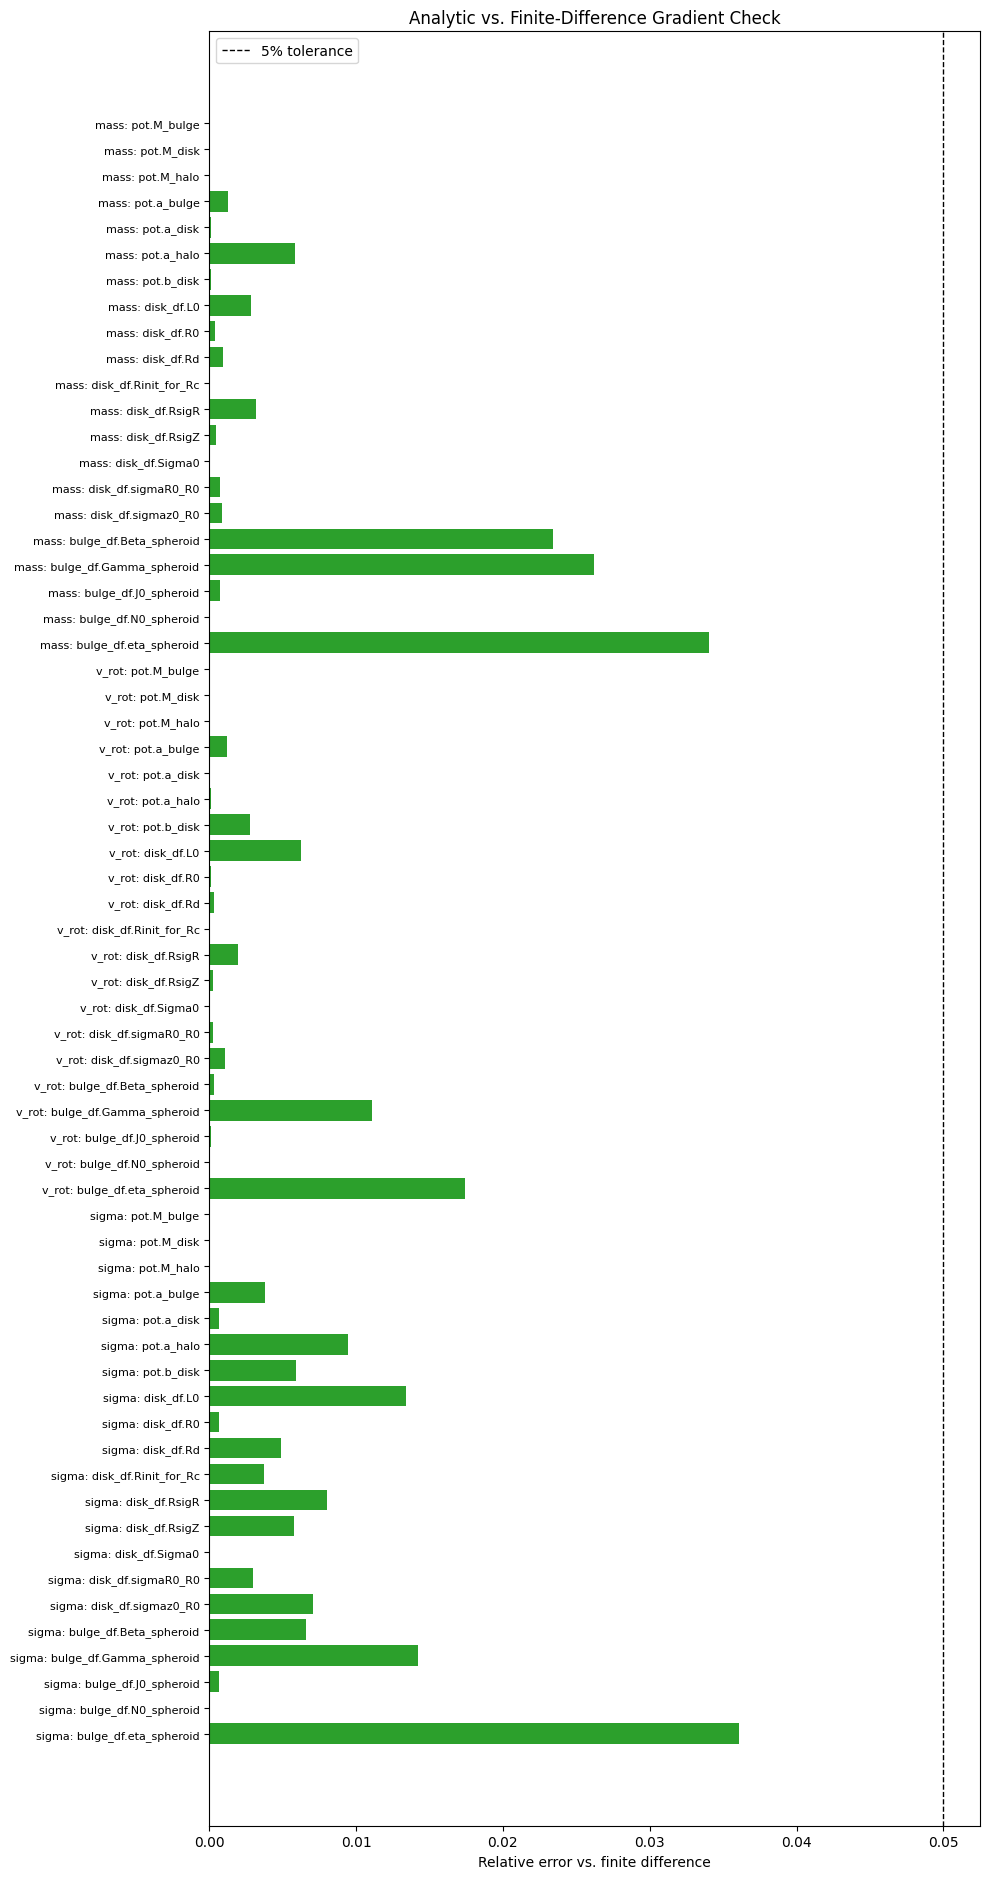

In [8]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(results))))
labels = [f"{r[0]}: {r[1].replace('_params','')}.{r[2]}" for r in results]
rel_errs = [r[5] for r in results]
colors = ['tab:green' if r[6] else 'tab:red' for r in results]

y_pos = np.arange(len(results))
ax.barh(y_pos, rel_errs, color=colors)
ax.axvline(RTOL, color='black', linestyle='--', linewidth=1, label=f'{RTOL:.0%} tolerance')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Relative error vs. finite difference')
ax.set_title('Analytic vs. Finite-Difference Gradient Check')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Conclusion

In [9]:
failed = [r for r in results if not r[-1]]
if not failed:
    print("All analytic gradients agree with finite differences within tolerance.")
    print("generate_edge_on_maps is differentiable and correct w.r.t. potential and DF parameters.")
else:
    print(f"{len(failed)} parameter(s) failed the gradient check:")
    for name, group, key, analytic, fd, rel_err, _ in failed:
        print(f"  - {name}: {group}.{key} (analytic={analytic:.4e}, finite-diff={fd:.4e}, rel.err={rel_err:.2%})")

All analytic gradients agree with finite differences within tolerance.
generate_edge_on_maps is differentiable and correct w.r.t. potential and DF parameters.
